In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
enforcement = pd.read_csv('enforcement_monthly_clustered.csv')
print(enforcement.head())

     month  removals  arrests  detentions  cluster    month_dt
0  2011-01         0        0         225        2  2011-01-01
1  2011-02         0        0         340        2  2011-02-01
2  2011-03         0        0         486        2  2011-03-01
3  2011-04         0        0         414        2  2011-04-01
4  2011-05         0        0         757        2  2011-05-01


In [3]:
#extracts year to merge with immigration data
enforcement['year'] = pd.to_datetime(enforcement['month']).dt.year

print(enforcement['year'].unique())

[2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021]


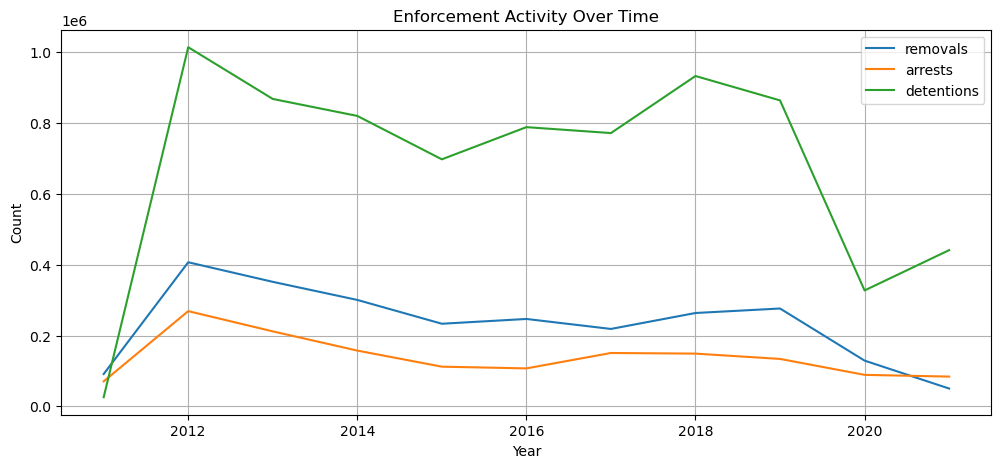

In [4]:
enforcement_annual = enforcement.groupby('year')[['removals', 'arrests', 'detentions']].sum()

enforcement_annual.plot(figsize=(12, 5))
plt.title('Enforcement Activity Over Time')
plt.xlabel('Year')
plt.ylabel('Count')
plt.grid(True)
plt.show()

As previously stated, a lot of the ice data only begins mid 2011 which is why in the dataframe and here in the graph there are a lot of 0's. To avoid major skewing, 2011 will be dropped going forward. 

It is also worth noting that the Consequence Delivery System (CDS) went into effect in 2011. CDS changed how the government handled people caught crossing the border illegally- now instead of sending them back quickly and voluntarily, they were being given formal removals. This could possibly explain why 2012 has high numbers in comparison to future years.

resources: https://www.migrationpolicy.org/research/advances-us-mexico-border-enforcement-review-consequence-delivery-system 

For the rest of this analysis we will be using DHS's noncitizen removals rather than ICE's removals. While both track removals and follow similar trends DHS's removals are potentially including border removals and other such data not captured in the ice dataset. Since our question focuses more on policy changes and immigration trends, DHS's removal data gives us a broader scope.

In [5]:
enforcement = enforcement[enforcement['year'] != 2011]
enforcement_annual = enforcement.groupby('year')[['removals', 'arrests', 'detentions']].sum()

In [6]:
immigration = pd.read_csv('immigration_cleaned.csv')

#filter to 2012-2021
immigration = immigration[(immigration['Year'] >= 2012) & (immigration['Year'] <= 2021)]
enforcement_annual = enforcement_annual.reset_index()

print(immigration.head())

      Year  Obtaintment of Permanent Residence  Refugee Arrivals  \
30  2012.0                           1031631.0           58179.0   
31  2013.0                            990553.0           69909.0   
32  2014.0                           1016518.0           69975.0   
33  2015.0                           1051031.0           69920.0   
34  2016.0                           1183505.0           84989.0   

    Noncitizen Apprehensions  Noncitizen Removals  Noncitizen Returns  
30                  795735.0             415579.0            231105.0  
31                  786223.0             432201.0            178973.0  
32                  805334.0             405026.0            163836.0  
33                  596560.0             324303.0            129636.0  
34                  683782.0             332263.0            106479.0  


Before merging the removals and immigration dataframes, we wanted to compare the ice and DHS removal counts and see if they were consistent with one another. 

In [7]:
#df to compare ice and DHS removals
immigration_compare = immigration[['Year', 'Noncitizen Removals']].copy()
immigration_compare.columns = ['year', 'DHS_removals']

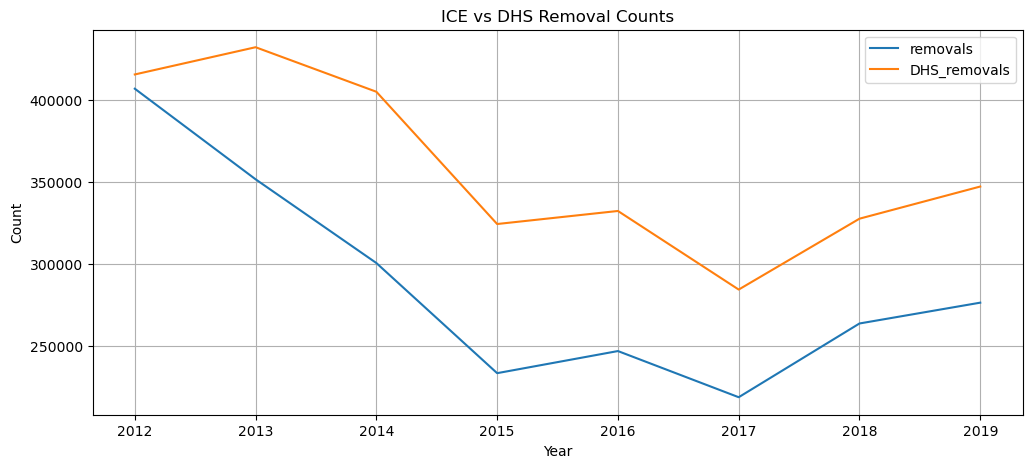

In [8]:
#plots removals from ice and immigration dataset
immigration_compare.columns = ['year', 'DHS_removals']

comparison = pd.merge(enforcement_annual, immigration_compare, on='year')
comparison.set_index('year')[['removals', 'DHS_removals']].plot(figsize=(12, 5))

plt.title('ICE vs DHS Removal Counts')
plt.xlabel('Year')
plt.ylabel('Count')
plt.grid(True)
plt.show()

The plot above shows that while there are differences in the number of removals within the ice and immigration data, they follow similar trends from 2014 and beyond the difference could be caused by the fact that the ice dataset is only tracking removals within their system while the immigration removals could also factor in people who leave voluntarily or removals at the border- which the ice data does not capture.

In [9]:
#merge the two dataframes and drop one of the year columns
merged = pd.merge(enforcement_annual, immigration, left_on='year', right_on='Year', how='inner')
merged = merged.drop(columns=['Year'])

print(merged.head())

   year  removals  arrests  detentions  Obtaintment of Permanent Residence  \
0  2012    406877   268854     1014094                           1031631.0   
1  2013    351603   211741      868057                            990553.0   
2  2014    300503   157439      820086                           1016518.0   
3  2015    233276   112042      697535                           1051031.0   
4  2016    246771   107181      788417                           1183505.0   

   Refugee Arrivals  Noncitizen Apprehensions  Noncitizen Removals  \
0           58179.0                  795735.0             415579.0   
1           69909.0                  786223.0             432201.0   
2           69975.0                  805334.0             405026.0   
3           69920.0                  596560.0             324303.0   
4           84989.0                  683782.0             332263.0   

   Noncitizen Returns  
0            231105.0  
1            178973.0  
2            163836.0  
3            1

In [12]:
corr = [
    'arrests', 'detentions',
    'Obtaintment of Permanent Residence',
    'Refugee Arrivals',
    'Noncitizen Apprehensions',
    'Noncitizen Removals',
    'Noncitizen Returns'
]

corr_matrix = merged[corr].corr()
corr_matrix[['Noncitizen Removals', 'arrests', 'detentions']].round(2)

,Noncitizen Removals,arrests,detentions
arrests,0.72,1.00,0.77
detentions,0.53,0.77,1.00
Obtaintment of Permanent Residence,-0.74,-0.53,-0.30
Refugee Arrivals,0.26,-0.03,-0.45
Noncitizen Apprehensions,0.31,0.11,0.41
Noncitizen Removals,1.00,0.72,0.53
Noncitizen Returns,0.79,0.82,0.83


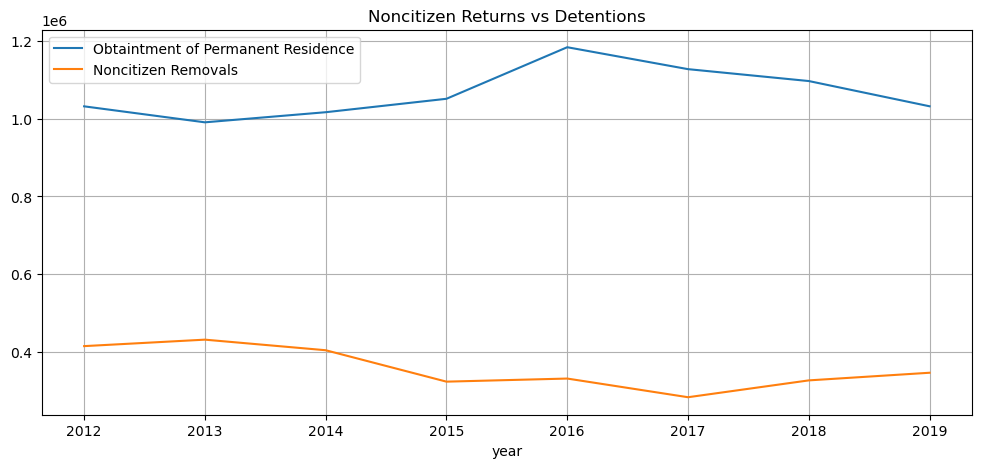

In [21]:
merged.set_index('year')[['Obtaintment of Permanent Residence', 'Noncitizen Removals']].plot(
    figsize=(12, 5)
)
plt.title('Noncitizen Returns vs Detentions')
plt.grid(True)
plt.show()

These correlation calculations and plots show that Noncitizen has a strong postive correlation with both arrests and detentions (0.82 and 0.83 respectively) however, we are not sure that this tells us any new information since it would be intuitve that as detentions and arrests increase, so do noncitizen returns. 

An interesting observation though, is that obtaintment of permanent residence and noncitizen removals has the highest negative correlation among immigration features.As enforcement increases, fewer people successfully obtain lawful permament resident status. It is important to note that enforcement patterns could be influenced by policy decisions, as we saw with the CDS implementation in 2011 which reclassified border returns as removals. Seeing as how the definition of what counts as removals has shifted over time, our data at the moment does not tell the full story. These findings suggest immigration enforcements in the U.S. are not uniform but could operate based on policy's of the time.